In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [34]:
df = pd.read_csv("train.csv")

In [35]:
df.loc[:,"Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

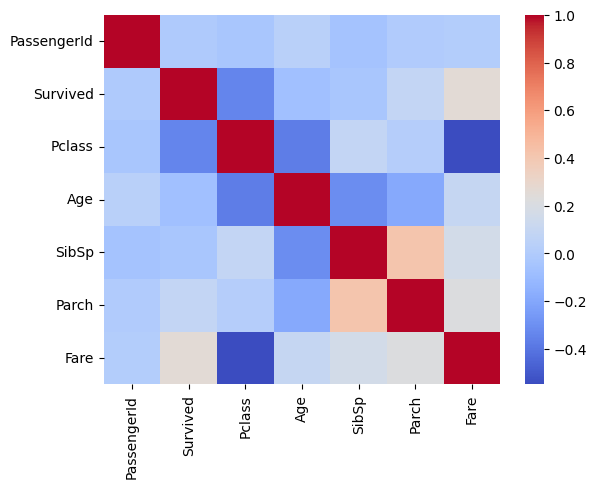

In [36]:
sns.heatmap( df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

In [37]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

numeric_features = ["Age", "Fare", "SibSp", "Parch", "Pclass"]
categorical_features = ["Sex", "Embarked"]

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="mean"), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier())
])


In [39]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "clf__n_estimators": [10, 100, 200, 500],
    "clf__max_depth": [None, 5, 10],
    "clf__min_samples_split": [2, 3, 4]
}

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring="accuracy")
grid.fit(df.drop("Survived", axis=1), df["Survived"])


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'clf__max_depth': [None, 5, ...], 'clf__min_samples_split': [2, 3, ...], 'clf__n_estimators': [10, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [40]:
df_test = pd.read_csv("test.csv")

In [41]:
prediction = grid.predict(df_test)

In [42]:
submission =  df_test[["PassengerId"]].copy()
submission["Survived"] = prediction


In [43]:
submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [44]:
submission.to_csv("submission.csv", index=False)